# Customer Churn Intelligence Platform

## Project Objective

Build an end-to-end customer churn analysis solution using Python and SQL to identify high-risk customers, analyze revenue impact, and generate actionable business insights.

### Tech Stack
- Python
- SQLite
- Pandas
- NumPy
- Matplotlib
- Seaborn
- VS Code
- Git & GitHub


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully! 🚀")

All libraries imported successfully! 🚀


In [3]:
import sqlite3

# Database path
db_path = "../data/raw/customer_churn.db"

# Connect database
conn = sqlite3.connect(db_path)

print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


In [4]:
# Show all tables in the database

query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = conn.execute(query).fetchall()

tables

[('db_customer',), ('db_subscription',), ('db_support',)]

In [5]:
# Show structure of db_customer

query = """
PRAGMA table_info(db_customer);
"""

customer_columns = conn.execute(query).fetchall()

customer_columns

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'name', 'TEXT', 0, None, 0),
 (2, 'country', 'TEXT', 0, None, 0),
 (3, 'state', 'TEXT', 0, None, 0),
 (4, 'gender', 'TEXT', 0, None, 0),
 (5, 'dob', 'TIMESTAMP', 0, None, 0),
 (6, 'interests', 'TEXT', 0, None, 0),
 (7, 'pincode', 'REAL', 0, None, 0)]

In [6]:
# Show structure of db_subscription

query = """
PRAGMA table_info(db_subscription);
"""

subscription_columns = conn.execute(query).fetchall()

subscription_columns

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'subscription_start_date', 'TEXT', 0, None, 0),
 (2, 'subscription_type', 'TEXT', 0, None, 0),
 (3, 'renewal_date', 'TEXT', 0, None, 0),
 (4, 'plan_type', 'TEXT', 0, None, 0),
 (5, 'contract_type', 'TEXT', 0, None, 0),
 (6, 'cancellation_date', 'TEXT', 0, None, 0),
 (7, 'cancellation_reason', 'TEXT', 0, None, 0),
 (8, 'monthly_charges', 'REAL', 0, None, 0),
 (9, 'cltv', 'INTEGER', 0, None, 0),
 (10, 'churn_score', 'INTEGER', 0, None, 0)]

In [7]:
# Show structure of db_support

query = """
PRAGMA table_info(db_support);
"""

support_columns = conn.execute(query).fetchall()

support_columns

[(0, 'customerid', 'TEXT', 0, None, 0),
 (1, 'complaint_date', 'TIMESTAMP', 0, None, 0),
 (2, 'escalations', 'TEXT', 0, None, 0),
 (3, 'csat_score', 'INTEGER', 0, None, 0),
 (4, 'col_1', 'REAL', 0, None, 0),
 (5, 'comment', 'TEXT', 0, None, 0)]

In [8]:
query = """
SELECT *
FROM db_customer
LIMIT 5;
"""

customer_df = pd.read_sql(query, conn)

customer_df

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
query = """
SELECT *
FROM db_subscription
LIMIT 5;
"""

subscription_df = pd.read_sql(query, conn)

subscription_df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [10]:
query = """
SELECT *
FROM db_support
LIMIT 5;
"""

support_df = pd.read_sql(query, conn)

support_df

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


# Exploratory Data Analysis (EDA)

In this section, we perform an initial exploration of the master dataset to understand its structure, identify missing values, inspect data types, and generate statistical summaries before data cleaning and visualization.

In [11]:
query = """

SELECT
    c.customerid,
    c.name,
    c.country,
    c.state,
    c.gender,
    c.dob,
    c.interests,
    c.pincode,

    s.subscription_start_date,
    s.subscription_type,
    s.renewal_date,
    s.plan_type,
    s.contract_type,
    s.cancellation_date,
    s.cancellation_reason,
    s.monthly_charges,
    s.cltv,
    s.churn_score,

    sp.complaint_date,
    sp.escalations,
    sp.csat_score,
    sp.comment

FROM db_customer c

LEFT JOIN db_subscription s
ON c.customerid = s.customerid

LEFT JOIN db_support sp
ON c.customerid = sp.customerid;

"""

master_df = pd.read_sql(query, conn)

master_df.head()

,customerid,name,country,state,gender,dob,interests,pincode,subscription_start_date,subscription_type,...,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,complaint_date,escalations,csat_score,comment
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None,2021-03-15,Refferal,...,Annual,NaN,NaN,13.99,627,12,NaN,NaN,NaN,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None,2020-08-01,Paid,...,Annual,2024-09-10,Switched to competitor,12.99,1150,91,2024-08-28 00:00:00,N,60.0,service issue
2,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None,2020-08-01,Paid,...,Annual,2024-09-10,Switched to competitor,12.99,1150,91,2024-08-28 00:00:00,Y,10.0,demaned refund
3,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None,2022-11-20,Organic,...,Monthly,NaN,NaN,6.99,210,34,NaN,NaN,NaN,NaN
4,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None,2019-05-10,Paid,...,Annual,NaN,NaN,22.99,1725,8,NaN,NaN,NaN,NaN


## Dataset Shape

Check the number of rows and columns available in the master dataset.

In [12]:
master_df.shape

(23, 22)

## Dataset Information

Inspect data types, memory usage, and missing values.

In [13]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               23 non-null     str    
 1   name                     23 non-null     str    
 2   country                  20 non-null     str    
 3   state                    23 non-null     str    
 4   gender                   23 non-null     str    
 5   dob                      23 non-null     str    
 6   interests                4 non-null      str    
 7   pincode                  0 non-null      object 
 8   subscription_start_date  23 non-null     str    
 9   subscription_type        23 non-null     str    
 10  renewal_date             23 non-null     str    
 11  plan_type                23 non-null     str    
 12  contract_type            23 non-null     str    
 13  cancellation_date        8 non-null      str    
 14  cancellation_reason      8 non-null    

## Statistical Summary

Generate descriptive statistics for numerical variables.

In [14]:
master_df.describe()

,monthly_charges,cltv,churn_score,csat_score
count,23.000000,23.000000,23.000000,9.000000
mean,18.511739,803.739130,47.782609,40.555556
std,16.975570,662.545382,34.226460,31.666667
min,6.990000,42.000000,3.000000,10.000000
25%,12.990000,235.000000,16.500000,20.000000
50%,13.990000,640.000000,41.000000,30.000000
75%,19.490000,1150.000000,81.000000,60.000000
max,92.990000,2185.000000,99.000000,90.000000


## Missing Values Analysis

Identify missing values present in each column.

In [15]:
master_df.isnull().sum()

customerid                  0
name                        0
country                     3
state                       0
gender                      0
dob                         0
interests                  19
pincode                    23
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason        15
monthly_charges             0
cltv                        0
churn_score                 0
complaint_date             14
escalations                14
csat_score                 14
comment                    19
dtype: int64

## Duplicate Records

Check for duplicate observations in the dataset.

In [16]:
master_df.duplicated().sum()

np.int64(0)

## Column Names

Display all column names.

In [17]:
master_df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'complaint_date', 'escalations', 'csat_score', 'comment'],
      dtype='str')

## Data Types

Display the data type of every column.

In [18]:
master_df.dtypes

customerid                     str
name                           str
country                        str
state                          str
gender                         str
dob                            str
interests                      str
pincode                     object
subscription_start_date        str
subscription_type              str
renewal_date                   str
plan_type                      str
contract_type                  str
cancellation_date              str
cancellation_reason            str
monthly_charges            float64
cltv                         int64
churn_score                  int64
complaint_date                 str
escalations                    str
csat_score                 float64
comment                        str
dtype: object

# Data Cleaning
Prepare the dataset by fixing data types, handling missing values, and removing unnecessary inconsistencies before analysis.

In [19]:
date_columns = [
    "dob",
    "subscription_start_date",
    "renewal_date",
    "cancellation_date",
    "complaint_date"
]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col], errors="coerce")

master_df.dtypes

customerid                            str
name                                  str
country                               str
state                                 str
gender                                str
dob                        datetime64[us]
interests                             str
pincode                            object
subscription_start_date    datetime64[us]
subscription_type                     str
renewal_date               datetime64[us]
plan_type                             str
contract_type                         str
cancellation_date          datetime64[us]
cancellation_reason                   str
monthly_charges                   float64
cltv                                int64
churn_score                         int64
complaint_date             datetime64[us]
escalations                           str
csat_score                        float64
comment                               str
dtype: object

# Missing Value Treatment
Handle missing values present in the dataset before performing analysis and visualization.

In [20]:
master_df.isnull().sum().sort_values(ascending=False)

pincode                    23
comment                    19
interests                  19
cancellation_date          15
cancellation_reason        15
csat_score                 14
escalations                14
complaint_date             14
country                     3
churn_score                 0
cltv                        0
monthly_charges             0
customerid                  0
contract_type               0
name                        0
renewal_date                0
subscription_type           0
subscription_start_date     0
dob                         0
gender                      0
state                       0
plan_type                   0
dtype: int64

# Convert Data Types
Convert date columns into proper datetime format for accurate analysis.

In [21]:
date_columns = [
    "dob",
    "subscription_start_date",
    "renewal_date",
    "cancellation_date",
    "complaint_date"
]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col], errors="coerce")

master_df[date_columns].dtypes

dob                        datetime64[us]
subscription_start_date    datetime64[us]
renewal_date               datetime64[us]
cancellation_date          datetime64[us]
complaint_date             datetime64[us]
dtype: object

# Fill Missing Values
Handle missing values using appropriate business logic for each column.

In [22]:
# Fill categorical columns

master_df["country"] = master_df["country"].fillna("Unknown")

master_df["interests"] = master_df["interests"].fillna("Unknown")

master_df["comment"] = master_df["comment"].fillna("No Comment")

master_df["escalations"] = master_df["escalations"].fillna("N")

master_df["cancellation_reason"] = master_df["cancellation_reason"].fillna("Not Cancelled")

In [23]:
# Fill date columns

master_df["complaint_date"] = master_df["complaint_date"].fillna(pd.NaT)

master_df["cancellation_date"] = master_df["cancellation_date"].fillna(pd.NaT)

In [24]:
# Fill numerical columns

master_df["csat_score"] = master_df["csat_score"].fillna(master_df["csat_score"].median())

In [25]:
# Drop useless column

master_df.drop(columns=["pincode"], inplace=True)

In [26]:
master_df.isnull().sum()

customerid                  0
name                        0
country                     0
state                       0
gender                      0
dob                         0
interests                   0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason         0
monthly_charges             0
cltv                        0
churn_score                 0
complaint_date             14
escalations                 0
csat_score                  0
comment                     0
dtype: int64

# Feature Engineering
Create new business features to improve analysis and derive meaningful customer insights.

In [27]:
master_df["customer_age"] = (
    (pd.Timestamp.today() - master_df["dob"]).dt.days // 365
)

master_df[["dob", "customer_age"]].head()

,dob,customer_age
0,1982-04-12,44
1,1995-11-23,30
2,1995-11-23,30
3,1978-02-15,48
4,2001-08-30,24


In [28]:
master_df["customer_tenure_days"] = (
    pd.Timestamp.today() - master_df["subscription_start_date"]
).dt.days

master_df[
    ["subscription_start_date", "customer_tenure_days"]
].head()

,subscription_start_date,customer_tenure_days
0,2021-03-15,1948
1,2020-08-01,2174
2,2020-08-01,2174
3,2022-11-20,1333
4,2019-05-10,2623


In [29]:
master_df["churn_status"] = master_df["cancellation_date"].apply(
    lambda x: "Churned" if pd.notnull(x) else "Active"
)

master_df["churn_status"].value_counts()

churn_status
Active     15
Churned     8
Name: count, dtype: int64

In [30]:
master_df["csat_category"] = master_df["csat_score"].apply(
    lambda x: "High" if x >= 80
    else "Medium" if x >= 50
    else "Low"
)

master_df["csat_category"].value_counts()

csat_category
Low       20
High       2
Medium     1
Name: count, dtype: int64

# Data Visualization
Visualize customer behavior, churn patterns, subscription trends, and satisfaction scores using charts and graphs.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

## Customer Churn Distribution
Analyze the proportion of active and churned customers.

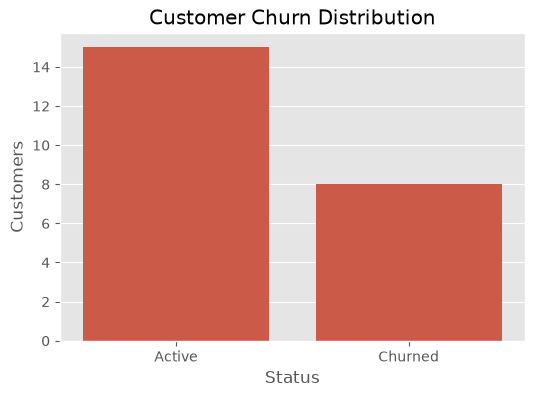

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=master_df,
    x="churn_status"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Status")
plt.ylabel("Customers")

plt.savefig(
    "../image/customer_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender Distribution
Analyze customer distribution based on gender.

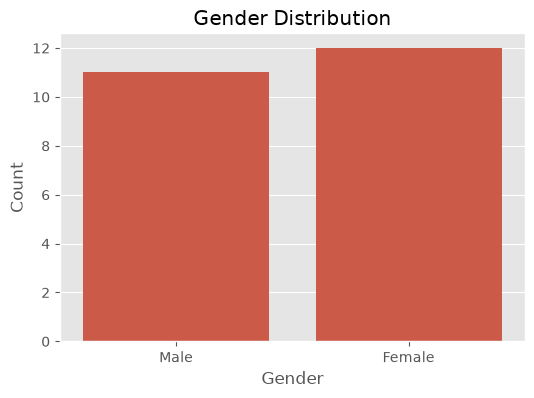

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=master_df,
    x="gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig(
    "../image/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
master_df["gender"] = master_df["gender"].replace({
    "Men": "Male",
    "Women": "Female"
})

## Subscription Type Distribution
Visualize different subscription sources.

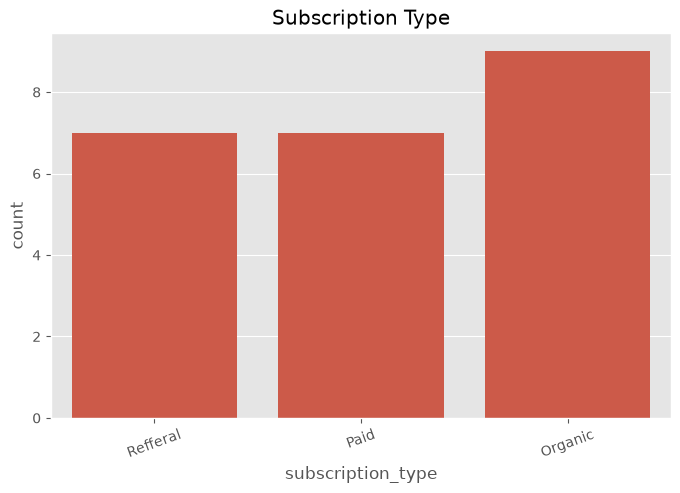

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master_df,
    x="subscription_type"
)

plt.title("Subscription Type")
plt.xticks(rotation=20)

plt.savefig(
    "../image/subscription_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Churn by Gender
Compare churn status across different genders.

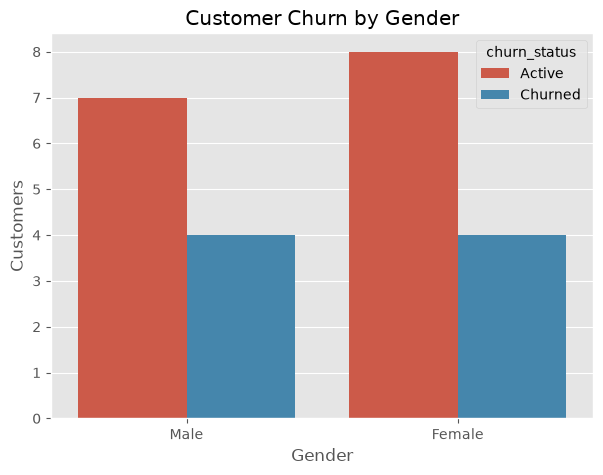

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=master_df,
    x="gender",
    hue="churn_status"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customers")

plt.savefig(
    "../image/churn_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Churn by Plan Type
Compare churn across different subscription plans.

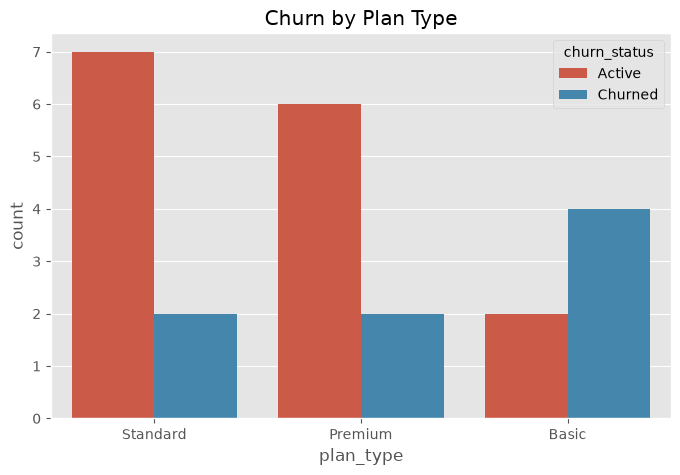

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master_df,
    x="plan_type",
    hue="churn_status"
)

plt.title("Churn by Plan Type")

plt.savefig(
    "../image/churn_by_plan_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monthly Charges Distribution
Understand the distribution of customer monthly charges.

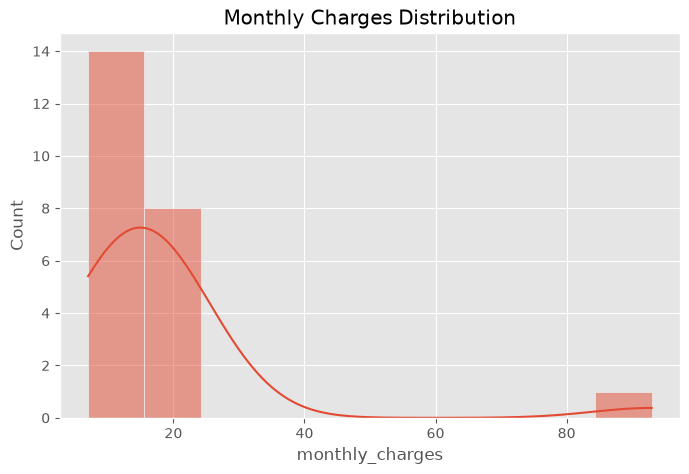

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    master_df["monthly_charges"],
    bins=10,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.savefig(
    "../image/monthly_charges_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Age Distribution
Analyze the age distribution of customers.

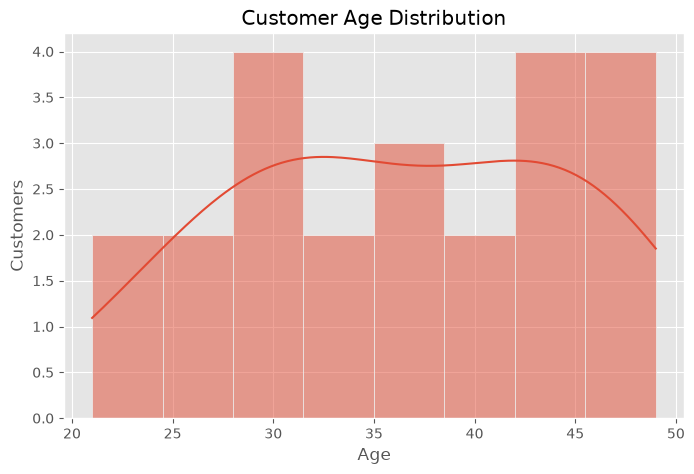

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    master_df["customer_age"],
    bins=8,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.savefig(
    "../image/customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Lifetime Value (CLTV) Distribution
Understand the distribution of customer lifetime value.

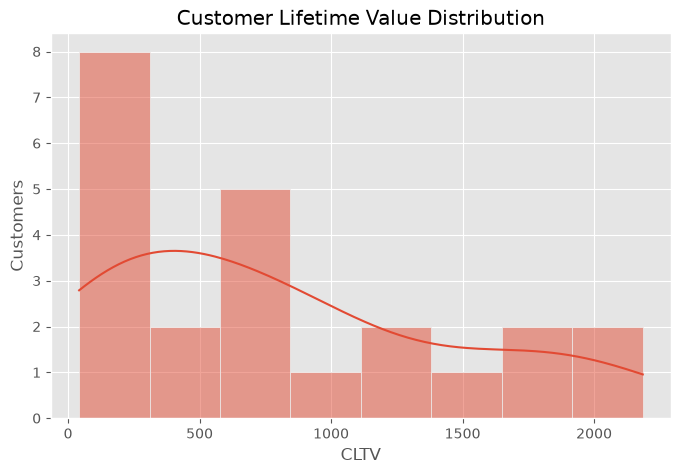

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
    master_df["cltv"],
    bins=8,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLTV")
plt.ylabel("Customers")

plt.savefig(
    "../image/cltv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## CSAT Category Distribution
Analyze customer satisfaction categories.

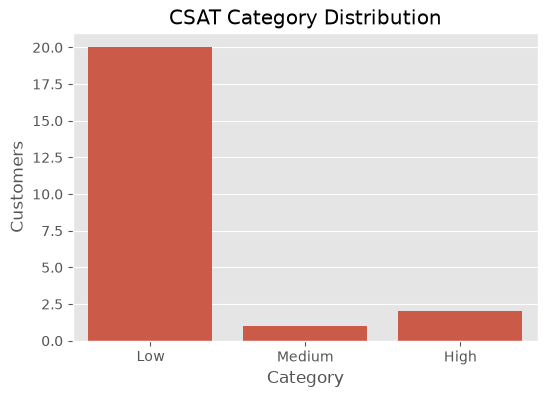

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=master_df,
    x="csat_category"
)

plt.title("CSAT Category Distribution")
plt.xlabel("Category")
plt.ylabel("Customers")

plt.savefig(
    "../image/csat_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top Customer States
Identify customers across different states.

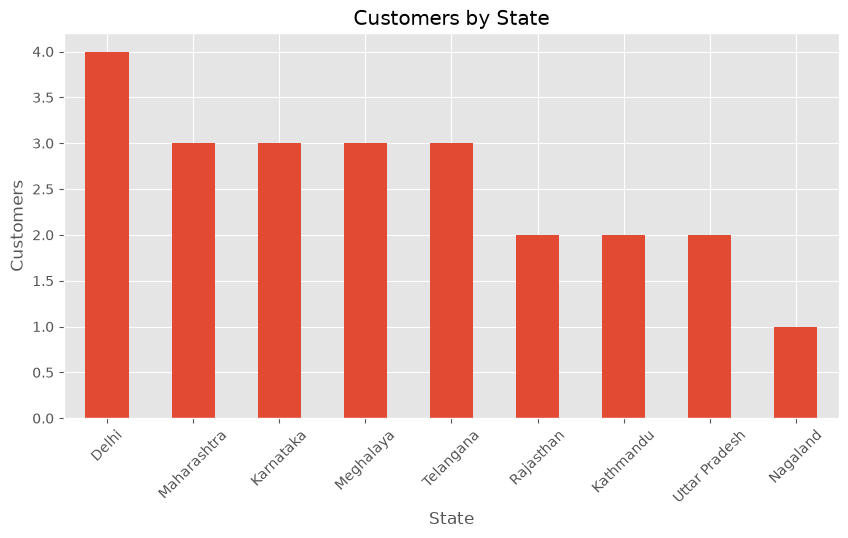

In [57]:
plt.figure(figsize=(10,5))

master_df["state"].value_counts().plot(kind="bar")

plt.title("Customers by State")
plt.xlabel("State")
plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.savefig(
    "../image/customers_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap
Visualize relationships among numerical variables.

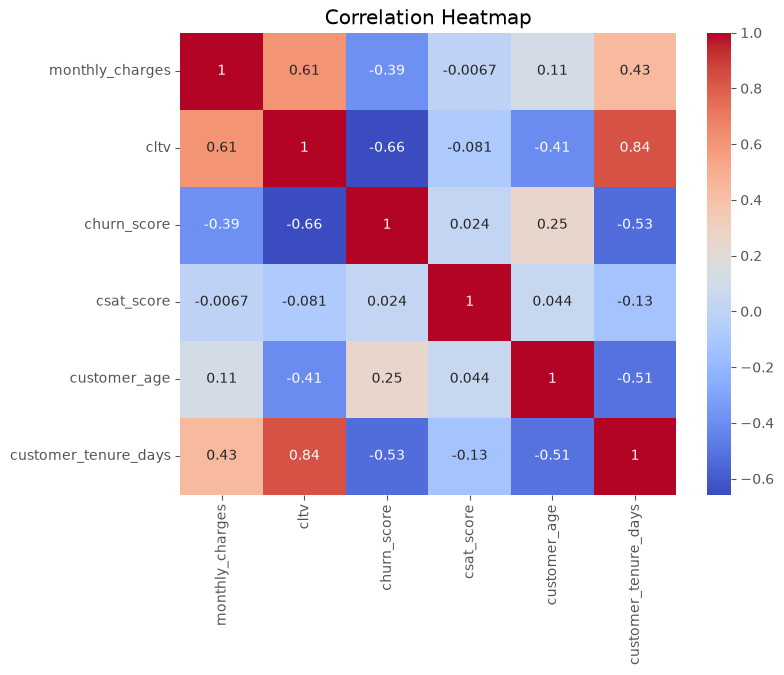

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    master_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../image/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insights
The following insights were derived from exploratory data analysis and visualizations.

## Key Findings

### 1. Customer Churn
- Majority of customers are Active.
- Around one-third of customers have churned.
### 2. Subscription Plans
- Basic Plan has the highest churn rate.
- Premium and Standard plans retain customers better.
### 3. Customer Satisfaction
- Most customers fall into the Low CSAT category.
- Very few customers reported High satisfaction.
### 4. Customer Lifetime Value
- Customers with longer tenure generally have higher CLTV.
- Higher CLTV customers are less likely to churn.
### 5. Monthly Charges
- Monthly charges are concentrated in the lower range.
- Few customers pay significantly higher monthly charges.
### 6. Customer Age
- Majority of customers belong to the age group of 28–48 years.
- Customer age shows only a weak relationship with churn.
### 7. Correlation Analysis
- CLTV and Customer Tenure have a strong positive correlation.
- Churn Score is negatively correlated with CLTV and Tenure.

# Business Recommendations
Based on the analysis, the following recommendations are suggested.
1. Improve retention strategies for customers using the Basic Plan, as this segment shows the highest churn.
2. Increase customer satisfaction by addressing complaints quickly.
3. Introduce loyalty rewards for long-tenure customers.
4. Improve onboarding experience for new customers.
5. Focus marketing campaigns on high-value customers.
6. Monitor churn score regularly for early intervention.

# Conclusion
The insights generated from this analysis can help businesses improve customer retention, optimize subscription plans, and increase customer lifetime value.
- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Exploratory Data Analysis
- Business Insights
- Business Recommendations

The analysis helps identify customer behavior patterns and provides actionable insights to reduce churn and improve customer retention.

In [45]:
master_df.to_csv(
    "../data/processed/cleaned_customer_churn.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully.")

✅ Cleaned dataset saved successfully.
